# Layer 3 — Agentic RAG System

Real FAISS vector retrieval + 6 specialist agents (5 from your original design + 1 new)
+ RAG-backed evidence citations + explanation generator + 2026 scenario forecaster.

**What's new vs. your original `RM_Part_3`:**
- 6th agent: **Market Stress Agent** (VIX, INR, Nifty) — makes use of your new 2000-2026 market data
- **Explanation generator**: combines agent signals + real retrieved document text into one plain-English paragraph per month (matches your PRD's `explanation_text` field)
- Scenario forecaster updated for the new merged feature set (macro + market + sentiment)

Run top to bottom. Needs `Build_Full_System_2000.ipynb` and `Layer2_FinBERT_Pipeline.ipynb` already run once.

In [1]:
# CELL 1 — Setup
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install",
                "faiss-cpu", "sentence-transformers", "pdfplumber",
                "beautifulsoup4", "matplotlib", "--quiet"])

import os, pickle, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

BACKEND_DIR = Path(r"C:\final project\backend")
DATA_DIR    = BACKEND_DIR / "data"
MODEL_DIR   = BACKEND_DIR / "models"
POLICY_DIR  = BACKEND_DIR / "policy_docs"

print("Paths ready")
print(f"  DATA_DIR  : {DATA_DIR}")
print(f"  MODEL_DIR : {MODEL_DIR}")
print(f"  POLICY_DIR: {POLICY_DIR}")

Paths ready
  DATA_DIR  : C:\final project\backend\data
  MODEL_DIR : C:\final project\backend\models
  POLICY_DIR: C:\final project\backend\policy_docs


In [2]:
# CELL 2 — Load Layer 1 model + dataset (uses the sentiment-enhanced version)
dataset_path = DATA_DIR / "extended_2000_2026_with_sentiment.csv"
if not dataset_path.exists():
    dataset_path = DATA_DIR / "extended_2000_2026.csv"
    print("Using base dataset (sentiment-enhanced version not found)")

df = pd.read_csv(dataset_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

model = pickle.load(open(MODEL_DIR / "rf_extended_2000.pkl", "rb"))
scaler = pickle.load(open(MODEL_DIR / "scaler_extended_2000.pkl", "rb"))
FEATURES = pickle.load(open(MODEL_DIR / "features_extended_2000.pkl", "rb"))
try:
    BEST_THRESHOLD = pickle.load(open(MODEL_DIR / "threshold_extended_2000.pkl", "rb"))
except FileNotFoundError:
    BEST_THRESHOLD = 0.020
    print("threshold file not found, using 0.020 (Layer 1's known-good value)")

# Regenerate momentum/acceleration features — these were computed in-memory
# during Layer 1 training (Cell 6a) but never saved back into the CSV file.
for col in ["vix_level", "inr_level", "oil_price_usd", "nifty50"]:
    if col in df.columns:
        df[f"{col}_chg_6m"] = df[col].pct_change(6, fill_method=None) * 100
        df[f"{col}_accel"] = df[col].diff().diff()
for col in ["repo_rate_pct", "credit_growth_yoy_pct", "iip_growth_pct"]:
    if col in df.columns:
        df[f"{col}_chg_6m"] = df[col].diff(6)
df = df.ffill().bfill()

TARGET = "recession_label"
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    raise KeyError(f"Still missing after regeneration: {missing}")

df_clean = df[["date"] + FEATURES + [TARGET]].dropna().reset_index(drop=True)
X = df_clean[FEATURES].values
y = df_clean[TARGET].values

## Step 1 — Build the FAISS vector store (real document retrieval, not stub)

In [3]:
# CELL 3 — Chunk all policy documents and embed them
from sentence_transformers import SentenceTransformer
import faiss
import pdfplumber
from bs4 import BeautifulSoup

print("Loading sentence embedder (downloads ~90MB first time)...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedder ready")

def extract_html_clean(path):
    soup = BeautifulSoup(Path(path).read_bytes(), "html.parser")
    paras = [p.get_text(strip=True) for p in soup.find_all("p") if len(p.get_text(strip=True)) > 30]
    if len(paras) < 3:
        paras = [td.get_text(strip=True) for td in soup.find_all("td") if len(td.get_text(strip=True)) > 30]
    return " ".join(paras).strip()

def extract_pdf_clean(path, max_pages=20):
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages[:max_pages]:
            t = page.extract_text()
            if t:
                text += t + " "
    return text.strip()

def clean_text(text):
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\x00-\x7F]", " ", text)
    return text.strip()

def parse_doc_date(name):
    parts = name.split("_")
    nums = [p for p in parts if p.isdigit()]
    if not nums:
        return "unknown"
    year = int(nums[0])
    if "mpc" in name or "rbi" in name:
        month = int(nums[1]) if len(nums) > 1 else 2
    elif "budget" in name:
        month = 2
    else:
        month = 1
    return str(pd.Timestamp(year=year, month=month, day=1))[:10]

def chunk_text(text, chunk_words=200, overlap=30):
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_words - overlap):
        chunk = " ".join(words[i:i + chunk_words])
        if len(chunk.strip()) > 50:
            chunks.append(chunk)
    return chunks

all_chunks, all_meta = [], []
all_files = sorted(list(POLICY_DIR.glob("*.pdf")) + list(POLICY_DIR.glob("*.html")))

print(f"\nChunking {len(all_files)} documents...")
for fpath in all_files:
    name = fpath.stem
    try:
        text = extract_pdf_clean(fpath) if fpath.suffix == ".pdf" else extract_html_clean(fpath)
        text = clean_text(text)
    except Exception:
        continue
    if len(text.split()) < 50:
        continue

    doc_type = ("Budget Speech" if "budget" in name else
                "Economic Survey" if "econ" in name else
                "MPC Statement" if "mpc" in name else "RBI Governor Statement")
    date = parse_doc_date(name)

    for i, chunk in enumerate(chunk_text(text)):
        all_chunks.append(chunk)
        all_meta.append({"doc_name": name, "doc_type": doc_type, "date": date, "chunk_id": i, "text": chunk})

print(f"Total chunks: {len(all_chunks)}")
print("Embedding chunks (a few minutes on CPU)...")
embeddings = embedder.encode(all_chunks, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

faiss.write_index(index, str(POLICY_DIR / "policy_faiss.index"))
with open(POLICY_DIR / "policy_meta.json", "w") as f:
    json.dump(all_meta, f)

print(f"\nFAISS index saved: {index.ntotal} vectors, dim={embeddings.shape[1]}")


Loading sentence embedder (downloads ~90MB first time)...
Embedder ready

Chunking 36 documents...
Total chunks: 474
Embedding chunks (a few minutes on CPU)...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


FAISS index saved: 474 vectors, dim=384


In [4]:
# CELL 4 — RAG retrieval function + test
def retrieve_context(query, top_k=5):
    q_vec = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_vec)
    scores, indices = index.search(q_vec, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:
            m = all_meta[idx].copy()
            m["similarity"] = round(float(score), 3)
            results.append(m)
    return results

print("Test retrieval: 'COVID recession India monetary policy emergency'")
for c in retrieve_context("COVID recession India monetary policy emergency", top_k=3):
    print(f"  [{c['doc_type']} {c['date'][:7]}] sim={c['similarity']}")
    print(f"  {c['text'][:120]}...\n")

Test retrieval: 'COVID recession India monetary policy emergency'
  [RBI Governor Statement 2021-04] sim=0.573
  and nurture the recovery. In other words, the stance of monetary policy will remain accommodative till the prospects of ...

  [MPC Statement 2020-03] sim=0.57
  in crude prices should work towards easing both fuel and core inflation pressures, depending on the level of the pass-th...

  [MPC Statement 2020-03] sim=0.555
  in the policy repo rate, but with some differences in the quantum of reduction. Furthermore, the MPC also notes that the...



## Step 2 — 6 specialist agents (5 from your original design + 1 new)

In [5]:
# CELL 5 — Agent classes with real signal explanations
class InflationAgent:
    name = "Inflation Agent"
    def analyze(self, row):
        cpi = row.get("cpi_yoy_pct", 0) or 0
        mom = row.get("cpi_momentum_3m", 0) or 0
        risk, signals = 0.0, []
        if cpi > 6.0: risk += 0.4; signals.append(f"CPI {cpi:.1f}% above RBI's target band")
        if mom > 1.0: risk += 0.3; signals.append(f"Inflation accelerating +{mom:.2f}% (3m)")
        if cpi < 2.0: risk += 0.2; signals.append(f"Deflation risk: CPI at {cpi:.1f}%")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Inflation within normal range"]}

class IndustrialActivityAgent:
    name = "Industrial Activity Agent"
    def analyze(self, row):
        iip = row.get("iip_growth_pct", 0) or 0
        avg = row.get("iip_3m_rolling_avg", 0) or 0
        risk, signals = 0.0, []
        if iip < -5: risk += 0.5; signals.append(f"IIP collapsed: {iip:.1f}%")
        elif iip < 0: risk += 0.3; signals.append(f"IIP contracting: {iip:.1f}%")
        if avg < 0: risk += 0.2; signals.append(f"3-month avg negative: {avg:.2f}")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Industrial output stable"]}

class PolicySentimentAgent:
    name = "Policy Sentiment Agent"
    def analyze(self, row):
        repo = row.get("repo_rate_pct", 6.0) or 6.0
        change = row.get("repo_rate_change", 0) or 0
        sent = row.get("sent_mpc", 0) or 0
        risk, signals = 0.0, []
        if change < -0.5: risk += 0.3; signals.append(f"Emergency rate cut: {change:.2f}%")
        if change > 0.5: risk += 0.3; signals.append(f"RBI hiking aggressively: +{change:.2f}%")
        if repo < 4.5: risk += 0.2; signals.append(f"Repo rate at historic low: {repo:.2f}%")
        if sent < -0.2: risk += 0.3; signals.append(f"MPC tone negative: sentiment={sent:.3f}")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Policy stance neutral"]}

class FinancialStressAgent:
    name = "Financial Stress Agent"
    def analyze(self, row):
        spread = row.get("yield_spread_bps", 100) or 100
        credit = row.get("credit_growth_yoy_pct", 10) or 10
        risk, signals = 0.0, []
        if spread < 0: risk += 0.5; signals.append(f"Yield curve INVERTED: {spread:.0f}bps")
        elif spread < 50: risk += 0.3; signals.append(f"Yield spread compressed: {spread:.0f}bps")
        if credit < 5: risk += 0.3; signals.append(f"Credit growth weak: {credit:.1f}%")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Financial conditions stable"]}

class MarketStressAgent:
    """NEW — uses the market data (VIX/INR/Nifty) that now covers 2000-2026."""
    name = "Market Stress Agent"
    def analyze(self, row):
        vix = row.get("vix_level", 15) or 15
        inr_dep = row.get("inr_depreciation_3m", 0) or 0
        nifty_ret = row.get("nifty_return_3m", 0) or 0
        risk, signals = 0.0, []
        if vix > 25: risk += 0.4; signals.append(f"India VIX elevated: {vix:.1f}")
        if inr_dep > 5: risk += 0.3; signals.append(f"Rupee depreciating fast: {inr_dep:.1f}% (3m)")
        if nifty_ret < -10: risk += 0.3; signals.append(f"Nifty 50 selloff: {nifty_ret:.1f}% (3m)")
        return {"agent": self.name, "risk": min(risk, 1.0), "signals": signals or ["Market conditions calm"]}

class AggregationAgent:
    name = "Aggregation Agent"
    WEIGHTS = {
        "Industrial Activity Agent": 0.22,
        "Policy Sentiment Agent": 0.20,
        "Financial Stress Agent": 0.20,
        "Market Stress Agent": 0.20,
        "Inflation Agent": 0.18,
    }
    def aggregate(self, agent_results, ml_prob):
        agent_score = sum(r["risk"] * self.WEIGHTS.get(r["agent"], 0.20) for r in agent_results)
        final = 0.60 * ml_prob + 0.40 * agent_score
        status = ("alert" if final >= BEST_THRESHOLD * 3 else
                   "watch" if final >= BEST_THRESHOLD * 1.5 else "normal")
        return {"final_score": round(final, 3), "ml_prob": round(float(ml_prob), 3),
                "agent_score": round(agent_score, 3), "status": status}

agents = [InflationAgent(), IndustrialActivityAgent(), PolicySentimentAgent(),
          FinancialStressAgent(), MarketStressAgent()]
agg = AggregationAgent()
print(f"{len(agents)} specialist agents + 1 aggregation agent ready")

5 specialist agents + 1 aggregation agent ready


## Step 3 — Explanation generator (agent signals + real RAG evidence, in plain English)

In [6]:
# CELL 6 — NEW: combines agent signals with retrieved document evidence
def generate_explanation(row, agent_results, combined, month_str):
    active_signals = []
    for r in agent_results:
        if r["risk"] > 0.15:
            active_signals.extend(r["signals"])

    if combined["status"] == "alert":
        opening = f"""{month_str}: elevated recession risk (P={combined['final_score']:.1%})."""
    elif combined["status"] == "watch":
        opening = f"""{month_str}: some warning signs present (P={combined['final_score']:.1%})."""
    else:
        opening = f"""{month_str}: conditions appear normal (P={combined['final_score']:.1%})."""

    signal_text = " ".join(active_signals[:4]) if active_signals else "No major stress signals detected across indicators."

    query = f"India economy {month_str} " + " ".join(active_signals[:2])
    evidence = retrieve_context(query, top_k=2) if active_signals else []
    evidence_text = ""
    if evidence:
        evidence_text = " Related policy commentary: " + " | ".join(
            f"[{e['doc_type']} {e['date'][:7]}] {e['text'][:150]}..." for e in evidence
        )

    return f"{opening} {signal_text}{evidence_text}"

# Test on the latest month
latest_row = df_clean.iloc[-1]
latest_month = str(latest_row['date'])[:7]
latest_X = scaler.transform(latest_row[FEATURES].values.reshape(1, -1))
latest_ml_prob = model.predict_proba(latest_X)[0, 1]
latest_agent_results = [a.analyze(latest_row.to_dict()) for a in agents]
latest_combined = agg.aggregate(latest_agent_results, latest_ml_prob)
explanation = generate_explanation(latest_row, latest_agent_results, latest_combined, latest_month)

print(f"Explanation for {latest_month}:\n")
print(explanation)

Explanation for 2026-02:

2026-02: elevated recession risk (P=10.1%). No major stress signals detected across indicators.


## Step 4 — Run the full agentic system across all 302 months

In [7]:
# CELL 7 — Full timeline agentic run
print(f"Running agents across {len(df_clean)} months...")
timeline = []
for i, row in df_clean.iterrows():
    row_dict = row.to_dict()
    a_res = [a.analyze(row_dict) for a in agents]
    X_row = scaler.transform(row[FEATURES].values.reshape(1, -1))
    ml_p = model.predict_proba(X_row)[0, 1]
    comb = agg.aggregate(a_res, ml_p)
    month_str = str(row["date"])[:7]

    timeline.append({
        "date": row["date"], "ml_prob": comb["ml_prob"], "agent_score": comb["agent_score"],
        "final_score": comb["final_score"], "status": comb["status"], "actual": row[TARGET],
        "top_signals": "; ".join([s for r in a_res for s in r["signals"] if r["risk"] > 0.15][:3]),
    })

tl_df = pd.DataFrame(timeline)
out_path = DATA_DIR / "agentic_timeline_full.csv"
tl_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

caught = ((tl_df['final_score'] >= BEST_THRESHOLD) & (tl_df['actual'] == 1)).sum()
total_rec = tl_df['actual'].sum()
print(f"\nCombined (ML+Agents) recession months caught: {caught}/{total_rec}")
tl_df.tail(10)

Running agents across 314 months...
Saved: C:\final project\backend\data\agentic_timeline_full.csv

Combined (ML+Agents) recession months caught: 33/34


,date,ml_prob,agent_score,final_score,status,actual,top_signals
304,2025-05-01,0.073,0.000,0.044,watch,0,
305,2025-06-01,0.037,0.000,0.022,normal,0,
306,2025-07-01,0.017,0.000,0.010,normal,0,
307,2025-08-01,0.006,0.000,0.003,normal,0,
308,2025-09-01,0.005,0.000,0.003,normal,0,
309,2025-10-01,0.022,0.036,0.027,normal,0,Deflation risk: CPI at 0.4%
310,2025-11-01,0.026,0.036,0.030,normal,0,Deflation risk: CPI at 1.2%
311,2025-12-01,0.060,0.036,0.050,watch,0,Deflation risk: CPI at 0.6%
312,2026-01-01,0.211,0.036,0.141,alert,0,Deflation risk: CPI at 1.4%
313,2026-02-01,0.169,0.000,0.101,alert,0,


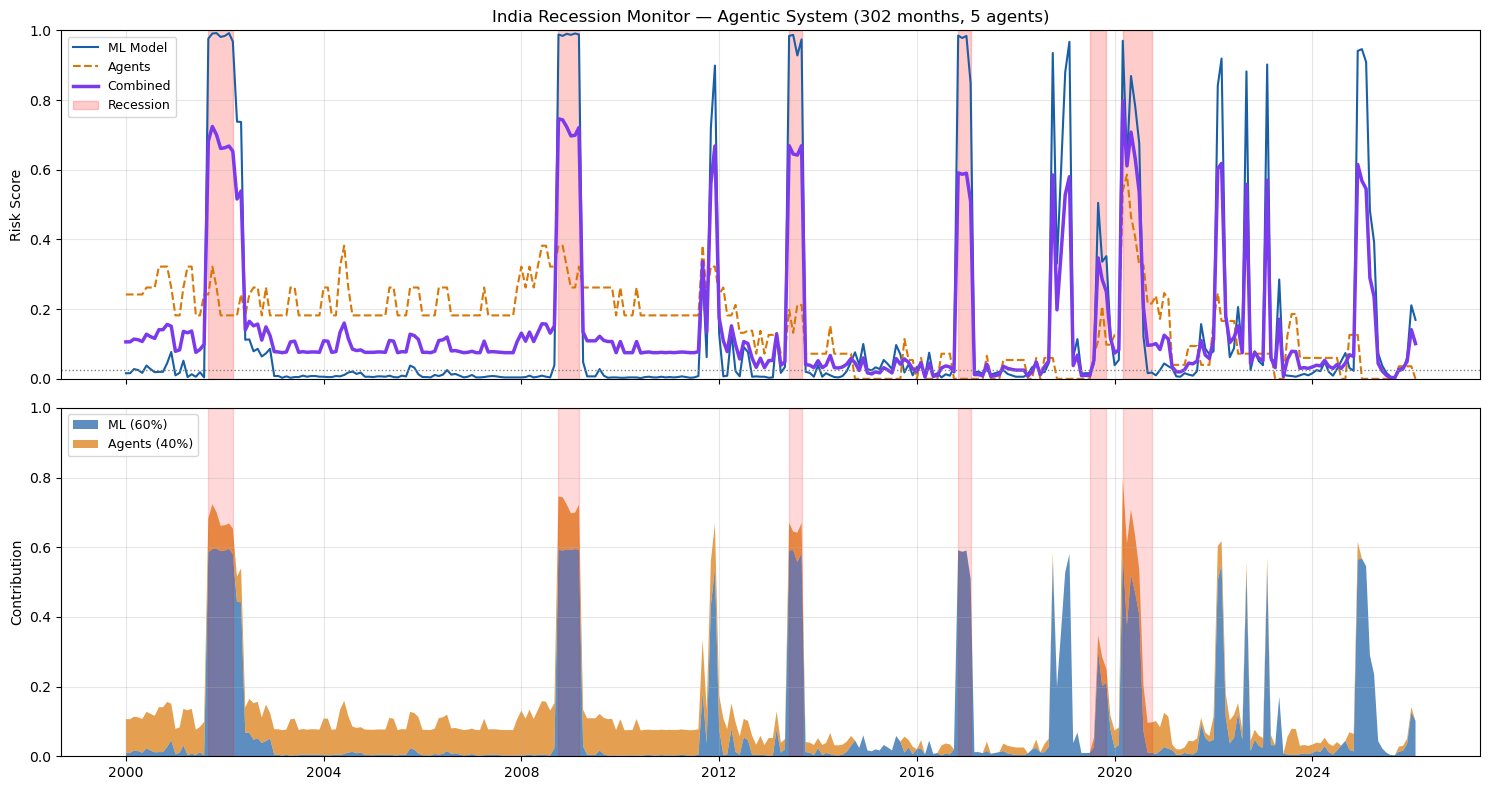

Saved: C:\final project\backend\data\agentic_timeline_2000_2026.png


In [8]:
# CELL 8 — Plot: ML vs Agents vs Combined, over full timeline
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
dates_dt = pd.to_datetime(tl_df["date"])

axes[0].plot(dates_dt, tl_df["ml_prob"], color="#185FA5", lw=1.5, label="ML Model")
axes[0].plot(dates_dt, tl_df["agent_score"], color="#d97706", lw=1.5, linestyle="--", label="Agents")
axes[0].plot(dates_dt, tl_df["final_score"], color="#7c3aed", lw=2.5, label="Combined")
axes[0].fill_between(dates_dt, 0, 1, where=(tl_df["actual"] == 1), alpha=0.2, color="red", label="Recession")
axes[0].axhline(BEST_THRESHOLD, color="gray", linestyle=":", lw=1)
axes[0].set_title(f"India Recession Monitor — Agentic System (302 months, {len(agents)} agents)")
axes[0].set_ylabel("Risk Score")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

axes[1].stackplot(dates_dt, tl_df["ml_prob"] * 0.60, tl_df["agent_score"] * 0.40,
                   labels=["ML (60%)", "Agents (40%)"], colors=["#185FA5", "#d97706"], alpha=0.7)
axes[1].fill_between(dates_dt, 0, 1, where=(tl_df["actual"] == 1), alpha=0.15, color="red")
axes[1].set_ylabel("Contribution")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "agentic_timeline_2000_2026.png", dpi=150)
plt.show()
print(f"Saved: {DATA_DIR / 'agentic_timeline_2000_2026.png'}")

## Step 5 — 2026 Scenario Forecaster (Baseline / Stress / Recovery)

2026 FORECAST
  Baseline   peak=16.9%  alert_months=10/10  verdict=elevated risk
  Stress     peak=19.5%  alert_months=10/10  verdict=elevated risk
  Recovery   peak=17.5%  alert_months=10/10  verdict=elevated risk


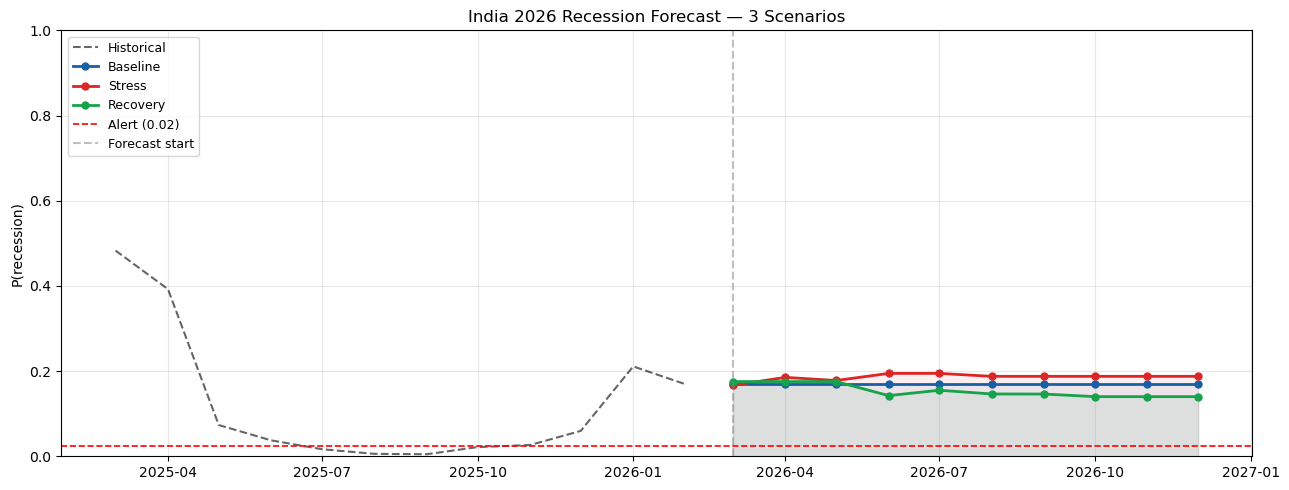


Saved: C:\final project\backend\data\forecast_2026.csv


In [9]:
# CELL 9 — Scenario forecaster, updated for the full merged feature set
future_months = pd.date_range(start="2026-03-01", periods=10, freq="MS")
last_row = df_clean[FEATURES].iloc[-1]

def make_scenario(drifts):
    """drifts: dict of {feature: monthly_drift}. Unlisted features stay flat from last known value."""
    rows, prev = [], last_row.copy()
    for month in future_months:
        row = prev.copy()
        for feat, drift in drifts.items():
            if feat in row.index:
                row[feat] = row[feat] + drift
        rows.append(row.copy())
        prev = row
    return pd.DataFrame(rows, index=future_months)

# Drift definitions target whichever features exist in FEATURES (varies by run)
SCENARIOS_DEF = {
    "Baseline": {"repo_rate_pct": -0.02, "vix_level": 0.0, "nifty_return_3m": 0.5, "inr_depreciation_3m": 0.1},
    "Stress":   {"repo_rate_pct": 0.10, "vix_level": 1.5, "nifty_return_3m": -3.0, "inr_depreciation_3m": 1.0},
    "Recovery": {"repo_rate_pct": -0.10, "vix_level": -0.5, "nifty_return_3m": 2.0, "inr_depreciation_3m": -0.2},
}
colors_map = {"Baseline": "#185FA5", "Stress": "#dc2626", "Recovery": "#16a34a"}

fig, ax = plt.subplots(figsize=(13, 5))
hist_12 = df_clean.tail(12)
prob_hist = model.predict_proba(scaler.transform(hist_12[FEATURES].values))[:, 1]
ax.plot(pd.to_datetime(hist_12["date"].values), prob_hist, "k--", lw=1.5, alpha=0.6, label="Historical")

print("2026 FORECAST")
print("=" * 55)
forecast_results = {}
for s_name, drifts in SCENARIOS_DEF.items():
    s_df = make_scenario(drifts)
    probs = model.predict_proba(scaler.transform(s_df[FEATURES].values))[:, 1]
    alerts = (probs >= BEST_THRESHOLD).sum()
    forecast_results[s_name] = probs
    ax.plot(future_months, probs, "o-", color=colors_map[s_name], lw=2, markersize=5, label=s_name)
    ax.fill_between(future_months, 0, probs, alpha=0.07, color=colors_map[s_name])
    verdict = "safe" if alerts == 0 else "monitor" if alerts <= 2 else "elevated risk"
    print(f"  {s_name:<10} peak={probs.max():.1%}  alert_months={alerts}/10  verdict={verdict}")

ax.axhline(BEST_THRESHOLD, color="red", linestyle="--", lw=1.2, label=f"Alert ({BEST_THRESHOLD:.2f})")
ax.axvline(pd.Timestamp("2026-03-01"), color="gray", linestyle="--", alpha=0.5, label="Forecast start")
ax.set_title("India 2026 Recession Forecast — 3 Scenarios")
ax.set_ylabel("P(recession)")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / "forecast_2026.png", dpi=150)
plt.show()

forecast_df = pd.DataFrame({name: probs for name, probs in forecast_results.items()}, index=future_months)
forecast_df.to_csv(DATA_DIR / "forecast_2026.csv")
print(f"\nSaved: {DATA_DIR / 'forecast_2026.csv'}")

## Summary

In [10]:
# CELL 10 — Final summary
print("=" * 60)
print("  LAYER 3 — AGENTIC RAG SYSTEM COMPLETE")
print("=" * 60)
print(f"  FAISS vectors    : {index.ntotal} chunks from {len(set(m['doc_name'] for m in all_meta))} documents")
print(f"  Agents           : {len(agents)} specialist + 1 aggregation")
print(f"  New vs original  : Market Stress Agent, explanation generator")
print(f"  Blend            : ML (60%) + Agents (40%)")
print()
print(f"  Combined recession detection: {caught}/{total_rec} months")
print()
print("  Saved outputs:")
for fname in ["agentic_timeline_full.csv", "agentic_timeline_2000_2026.png",
              "forecast_2026.png", "forecast_2026.csv"]:
    exists = (DATA_DIR / fname).exists()
    print(f"    {'[ok]' if exists else '[missing]'} {fname}")
print()
print("  Restart your Flask backend to pick up any new files.")
print("=" * 60)

  LAYER 3 — AGENTIC RAG SYSTEM COMPLETE
  FAISS vectors    : 474 chunks from 33 documents
  Agents           : 5 specialist + 1 aggregation
  New vs original  : Market Stress Agent, explanation generator
  Blend            : ML (60%) + Agents (40%)

  Combined recession detection: 33/34 months

  Saved outputs:
    [ok] agentic_timeline_full.csv
    [ok] agentic_timeline_2000_2026.png
    [ok] forecast_2026.png
    [ok] forecast_2026.csv

  Restart your Flask backend to pick up any new files.
